# EX 7 – Generate Synthetic Images Using a GAN (Fashion-MNIST, auto-downloaded)
**Change the name and roll number in the first code cell.**

## PART A – Dataset preparation and preprocessing

Name: Harish M K | Roll No: 24BAD031
Number of training images: 60000
Image dimensions: (28, 28)
Pixel range before normalization: 0 - 255


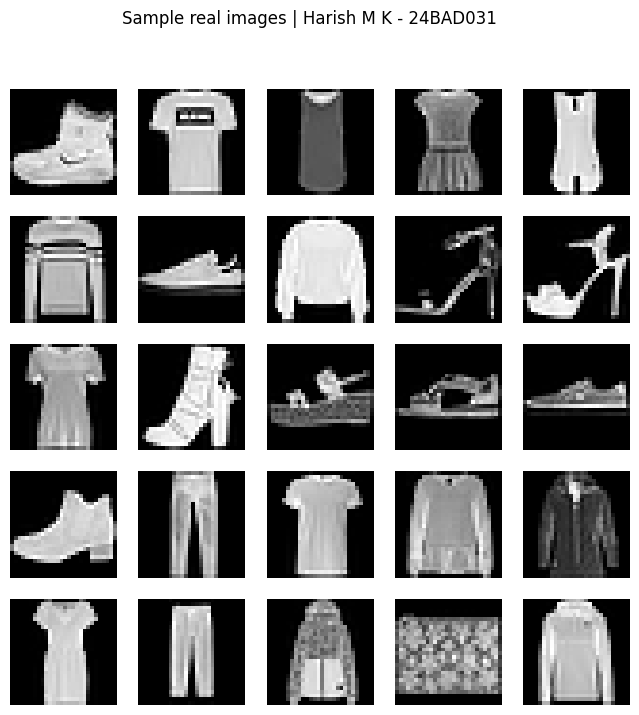

After preprocessing: (60000, 28, 28, 1) | range: -1.0 to 1.0
[Harish M K - 24BAD031] Batches per epoch: 469


In [ ]:
STUDENT_NAME = "Harish M K"
ROLL_NO      = "24BAD031"
print(f"Name: {STUDENT_NAME} | Roll No: {ROLL_NO}")

import numpy as np, pandas as pd, matplotlib.pyplot as plt, os, time
import tensorflow as tf
from tensorflow.keras import layers, models

# Dataset downloads automatically from the internet (no upload needed)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
class_names = ["T-shirt","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]

print("Number of training images:", x_train.shape[0])
print("Image dimensions:", x_train.shape[1:])
print("Pixel range before normalization:", x_train.min(), "-", x_train.max())

# Show sample real images
plt.figure(figsize=(8,8))
for i in range(25):
    plt.subplot(5,5,i+1); plt.imshow(x_train[i], cmap="gray"); plt.axis("off")
plt.suptitle(f"Sample real images | {STUDENT_NAME} - {ROLL_NO}")
plt.show()

# Normalize to [-1, 1] and reshape to (28,28,1)
x = (x_train.astype("float32") - 127.5) / 127.5
x = x.reshape(-1, 28, 28, 1)
print("After preprocessing:", x.shape, "| range:", x.min(), "to", x.max())

# tf.data pipeline
BUFFER_SIZE, BATCH_SIZE = 60000, 128
dataset = tf.data.Dataset.from_tensor_slices(x).shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
print(f"[{STUDENT_NAME} - {ROLL_NO}] Batches per epoch:", len(dataset))

## PART B – Generator

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,945 (8.89 MB)

 Trainable params: 2,305,473 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

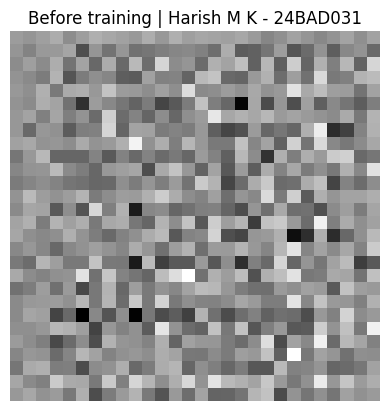

In [ ]:
NOISE_DIM = 100

def build_generator():
    model = models.Sequential([
        layers.Input(shape=(NOISE_DIM,)),
        layers.Dense(7*7*256, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Reshape((7, 7, 256)),
        layers.Conv2DTranspose(128, 5, strides=1, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Conv2DTranspose(64, 5, strides=2, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Conv2DTranspose(1, 5, strides=2, padding="same", activation="tanh"),
    ], name="generator")
    return model

generator = build_generator()
generator.summary()

# Image generated from random noise BEFORE training
noise = tf.random.normal([1, NOISE_DIM])
img = generator(noise, training=False)
plt.imshow(img[0, :, :, 0], cmap="gray"); plt.axis("off")
plt.title(f"Before training | {STUDENT_NAME} - {ROLL_NO}")
plt.show()

## PART C – Discriminator and GAN model

In [ ]:
def build_discriminator():
    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(64, 5, strides=2, padding="same"),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        layers.Conv2D(128, 5, strides=2, padding="same"),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(1, activation="sigmoid"),
    ], name="discriminator")
    return model

discriminator = build_discriminator()
discriminator.compile(optimizer=tf.keras.optimizers.Adam(1e-4, beta_1=0.5),
                      loss="binary_crossentropy", metrics=["accuracy"])

# Combined GAN (discriminator frozen inside the GAN)
discriminator.trainable = False
gan_input = layers.Input(shape=(NOISE_DIM,))
gan_output = discriminator(generator(gan_input))
gan = models.Model(gan_input, gan_output, name="gan")
gan.compile(optimizer=tf.keras.optimizers.Adam(1e-4, beta_1=0.5), loss="binary_crossentropy")

print(f"=== Generator Summary | {STUDENT_NAME} - {ROLL_NO} ===")
generator.summary()
print(f"=== Discriminator Summary | {STUDENT_NAME} - {ROLL_NO} ===")
discriminator.summary()
print(f"=== GAN Summary | {STUDENT_NAME} - {ROLL_NO} ===")
gan.summary()

=== Generator Summary | Harish M K - 24BAD031 ===


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,601 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,945 (8.89 MB)

 Trainable params: 2,305,473 (8.79 MB)

...

Model: "gan"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ generator (Sequential)          │ (None, 28, 28, 1)      │     2,330,945 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ discriminator (Sequential)      │ (None, 1)              │       212,865 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,543,810 (9.70 MB)

 Trainable params: 2,305,473 (8.79 MB)

 Non-trainable params: 238,337 (931.00 KB)

## PART D – Training, visualization and saving images

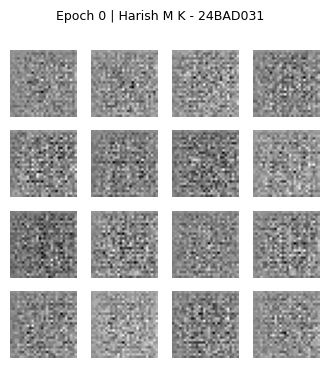

[24BAD031] Epoch 1/50 | D loss: 0.3721 | G loss: 0.1214 | 38.7s


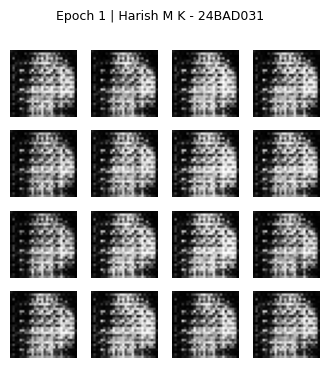

[24BAD031] Epoch 2/50 | D loss: 0.4780 | G loss: 0.2382 | 17.4s
[24BAD031] Epoch 3/50 | D loss: 0.5708 | G loss: 0.4588 | 17.7s
[24BAD031] Epoch 4/50 | D loss: 0.6050 | G loss: 0.5607 | 17.4s
[24BAD031] Epoch 5/50 | D loss: 0.6240 | G loss: 0.6175 | 17.7s
[24BAD031] Epoch 6/50 | D loss: 0.6362 | G loss: 0.6531 | 18.1s
[24BAD031] Epoch 7/50 | D loss: 0.6444 | G loss: 0.6774 | 18.1s
[24BAD031] Epoch 8/50 | D loss: 0.6503 | G loss: 0.6953 | 18.5s
[24BAD031] Epoch 9/50 | D loss: 0.6547 | G loss: 0.7092 | 18.1s
[24BAD031] Epoch 10/50 | D loss: 0.6581 | G loss: 0.7201 | 18.5s


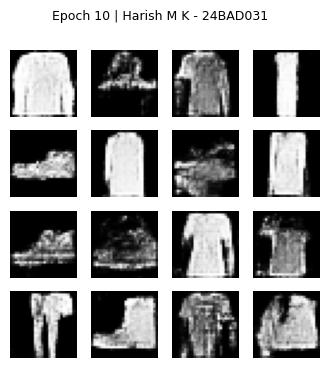

[24BAD031] Epoch 11/50 | D loss: 0.6608 | G loss: 0.7289 | 18.0s
[24BAD031] Epoch 12/50 | D loss: 0.6630 | G loss: 0.7362 | 18.3s
[24BAD031] Epoch 13/50 | D loss: 0.6648 | G loss: 0.7423 | 18.0s
[24BAD031] Epoch 14/50 | D loss: 0.6664 | G loss: 0.7475 | 18.3s
[24BAD031] Epoch 15/50 | D loss: 0.6676 | G loss: 0.7519 | 18.1s
[24BAD031] Epoch 16/50 | D loss: 0.6687 | G loss: 0.7559 | 18.2s
[24BAD031] Epoch 17/50 | D loss: 0.6696 | G loss: 0.7592 | 18.1s
[24BAD031] Epoch 18/50 | D loss: 0.6704 | G loss: 0.7622 | 18.0s
[24BAD031] Epoch 19/50 | D loss: 0.6711 | G loss: 0.7648 | 18.3s
[24BAD031] Epoch 20/50 | D loss: 0.6717 | G loss: 0.7673 | 18.2s


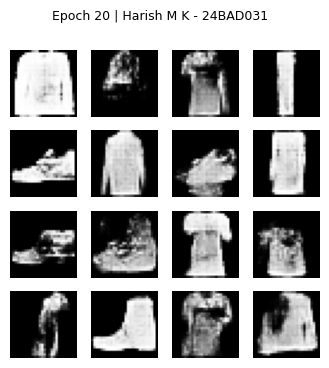

[24BAD031] Epoch 21/50 | D loss: 0.6722 | G loss: 0.7695 | 18.4s
[24BAD031] Epoch 22/50 | D loss: 0.6725 | G loss: 0.7714 | 17.9s
[24BAD031] Epoch 23/50 | D loss: 0.6726 | G loss: 0.7733 | 18.3s
[24BAD031] Epoch 24/50 | D loss: 0.6721 | G loss: 0.7756 | 18.1s
[24BAD031] Epoch 25/50 | D loss: 0.6717 | G loss: 0.7778 | 18.3s
[24BAD031] Epoch 26/50 | D loss: 0.6711 | G loss: 0.7798 | 18.0s
[24BAD031] Epoch 27/50 | D loss: 0.6704 | G loss: 0.7820 | 18.4s
[24BAD031] Epoch 28/50 | D loss: 0.6687 | G loss: 0.7864 | 17.9s
[24BAD031] Epoch 29/50 | D loss: 0.6675 | G loss: 0.7897 | 18.1s
[24BAD031] Epoch 30/50 | D loss: 0.6673 | G loss: 0.7917 | 18.1s


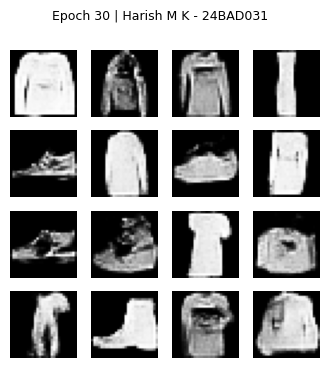

[24BAD031] Epoch 31/50 | D loss: 0.6669 | G loss: 0.7927 | 18.1s
[24BAD031] Epoch 32/50 | D loss: 0.6666 | G loss: 0.7937 | 18.1s
[24BAD031] Epoch 33/50 | D loss: 0.6658 | G loss: 0.7960 | 18.0s
[24BAD031] Epoch 34/50 | D loss: 0.6648 | G loss: 0.7988 | 18.3s
[24BAD031] Epoch 35/50 | D loss: 0.6640 | G loss: 0.8017 | 17.9s
[24BAD031] Epoch 36/50 | D loss: 0.6630 | G loss: 0.8043 | 18.3s
[24BAD031] Epoch 37/50 | D loss: 0.6621 | G loss: 0.8068 | 18.2s
[24BAD031] Epoch 38/50 | D loss: 0.6614 | G loss: 0.8092 | 18.3s
[24BAD031] Epoch 39/50 | D loss: 0.6607 | G loss: 0.8112 | 18.0s
[24BAD031] Epoch 40/50 | D loss: 0.6605 | G loss: 0.8127 | 18.2s


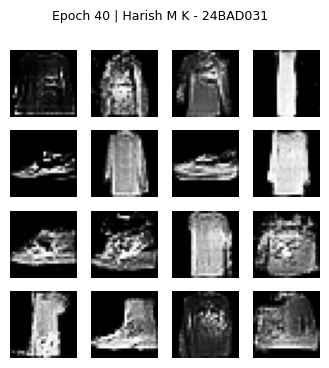

[24BAD031] Epoch 41/50 | D loss: 0.6601 | G loss: 0.8141 | 18.3s
[24BAD031] Epoch 42/50 | D loss: 0.6595 | G loss: 0.8159 | 18.3s
[24BAD031] Epoch 43/50 | D loss: 0.6587 | G loss: 0.8180 | 18.3s
[24BAD031] Epoch 44/50 | D loss: 0.6581 | G loss: 0.8204 | 18.1s
[24BAD031] Epoch 45/50 | D loss: 0.6576 | G loss: 0.8227 | 18.6s
[24BAD031] Epoch 46/50 | D loss: 0.6568 | G loss: 0.8249 | 18.0s
[24BAD031] Epoch 47/50 | D loss: 0.6561 | G loss: 0.8271 | 18.3s
[24BAD031] Epoch 48/50 | D loss: 0.6553 | G loss: 0.8292 | 17.9s
[24BAD031] Epoch 49/50 | D loss: 0.6546 | G loss: 0.8313 | 18.3s
[24BAD031] Epoch 50/50 | D loss: 0.6541 | G loss: 0.8332 | 18.1s


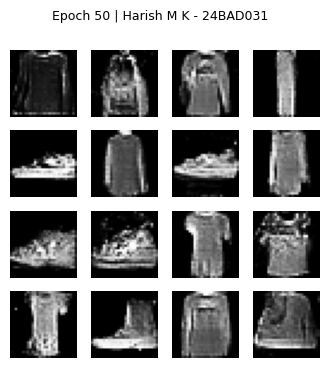

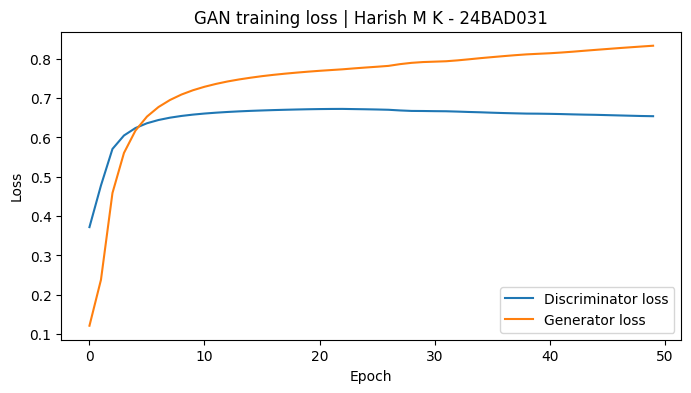

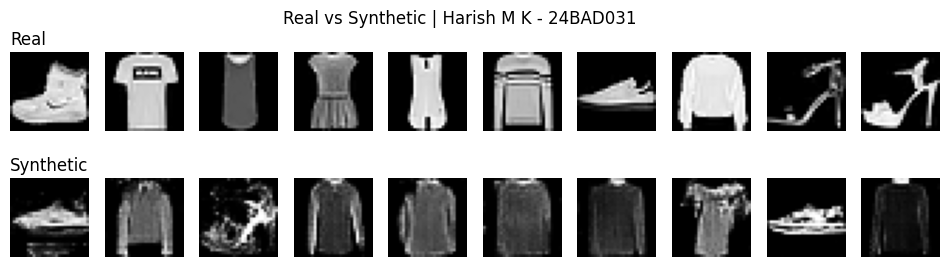

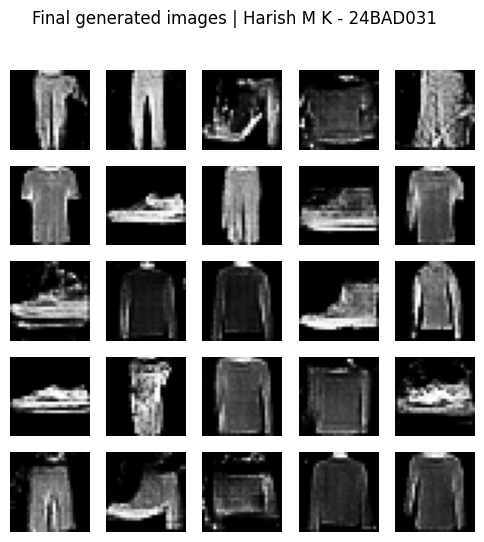

Saved to /content/generated_images/


In [ ]:
EPOCHS = 50
SAVE_INTERVAL = 10
os.makedirs("generated_images", exist_ok=True)
seed = tf.random.normal([16, NOISE_DIM])      # fixed noise to track progress

def show_images(model, epoch, save=True):
    preds = model(seed, training=False)
    plt.figure(figsize=(4,4))
    for i in range(16):
        plt.subplot(4,4,i+1)
        plt.imshow(preds[i,:,:,0]*127.5+127.5, cmap="gray"); plt.axis("off")
    plt.suptitle(f"Epoch {epoch} | {STUDENT_NAME} - {ROLL_NO}", fontsize=9)
    if save: plt.savefig(f"generated_images/epoch_{epoch:03d}.png")
    plt.show()

d_losses, g_losses = [], []
show_images(generator, 0)

for epoch in range(1, EPOCHS+1):
    start = time.time()
    d_ep, g_ep = [], []
    for real_batch in dataset:
        bs = real_batch.shape[0]
        noise = tf.random.normal([bs, NOISE_DIM])
        fake_batch = generator(noise, training=False)

        # 1) Train discriminator on real (1) and fake (0) images
        discriminator.trainable = True
        d_real = discriminator.train_on_batch(real_batch, tf.ones((bs,1))*0.9)   # label smoothing
        d_fake = discriminator.train_on_batch(fake_batch, tf.zeros((bs,1)))
        d_loss = 0.5*(d_real[0] + d_fake[0])

        # 2) Train generator via GAN (try to fool discriminator)
        discriminator.trainable = False
        noise = tf.random.normal([bs, NOISE_DIM])
        g_loss = gan.train_on_batch(noise, tf.ones((bs,1)))

        d_ep.append(d_loss); g_ep.append(g_loss)

    d_losses.append(np.mean(d_ep)); g_losses.append(np.mean(g_ep))
    print(f"[{ROLL_NO}] Epoch {epoch}/{EPOCHS} | D loss: {d_losses[-1]:.4f} | G loss: {g_losses[-1]:.4f} | {time.time()-start:.1f}s")
    if epoch % SAVE_INTERVAL == 0 or epoch == 1:
        show_images(generator, epoch)

# Loss curves
plt.figure(figsize=(8,4))
plt.plot(d_losses, label="Discriminator loss"); plt.plot(g_losses, label="Generator loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.title(f"GAN training loss | {STUDENT_NAME} - {ROLL_NO}")
plt.savefig("generated_images/loss_curve.png"); plt.show()

pd.DataFrame({"epoch": range(1, EPOCHS+1), "d_loss": d_losses, "g_loss": g_losses}).to_csv("generated_images/losses.csv", index=False)

# Real vs synthetic comparison
fake = generator(tf.random.normal([10, NOISE_DIM]), training=False)
plt.figure(figsize=(12,3))
for i in range(10):
    plt.subplot(2,10,i+1); plt.imshow(x_train[i], cmap="gray"); plt.axis("off")
    if i == 0: plt.title("Real", loc="left")
    plt.subplot(2,10,i+11); plt.imshow(fake[i,:,:,0]*127.5+127.5, cmap="gray"); plt.axis("off")
    if i == 0: plt.title("Synthetic", loc="left")
plt.suptitle(f"Real vs Synthetic | {STUDENT_NAME} - {ROLL_NO}")
plt.savefig("generated_images/real_vs_synthetic.png"); plt.show()

# Save final generated images + model
final = generator(tf.random.normal([25, NOISE_DIM]), training=False)
plt.figure(figsize=(6,6))
for i in range(25):
    plt.subplot(5,5,i+1); plt.imshow(final[i,:,:,0]*127.5+127.5, cmap="gray"); plt.axis("off")
plt.suptitle(f"Final generated images | {STUDENT_NAME} - {ROLL_NO}")
plt.savefig("generated_images/final_generated.png"); plt.show()
generator.save("generated_images/generator_final.keras")
print("Saved to /content/generated_images/")